# Sentiment Analysis Notebook

## 0. Setup

All libraries and reusable loading/helper functions are kept at the top of the notebook.

In [1]:
!pip install nbformat


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Libraries
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import opinion_lexicon
from nltk.corpus import stopwords
from scipy.stats import mannwhitneyu, pearsonr
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

import seaborn as sns

from transformers import pipeline


In [3]:
# Reusable constants and loading/helper functions

NEGATORS = {
    "no", "not", "nor", "never", "none", "neither", "cannot",
    "hardly", "rarely", "barely", "n't", "dont", "don't", "isn't", "wasn't",
    "aren't", "won't", "shouldn't", "couldn't", "wouldn't", "doesn't",
    "didn't", "haven't", "hasn't", "hadn't", "can't", "cant"
}


def load_bing_lexicon():
    """Load the Bing-style positive/negative opinion lexicon from NLTK."""
    nltk.download("opinion_lexicon", quiet=True)

    positive_words = opinion_lexicon.positive()
    negative_words = opinion_lexicon.negative()

    return pd.DataFrame({
        "word": list(positive_words) + list(negative_words),
        "sentiment": ["positive"] * len(positive_words) + ["negative"] * len(negative_words)
    })


def load_afinn_lexicon(local_path="AFINN-111.txt"):
    """Load the AFINN lexicon from a local file or, if missing, from GitHub."""
    local_path = Path(local_path)
    afinn_url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"

    source = local_path if local_path.exists() else afinn_url

    afinn = pd.read_csv(
        source,
        sep="\t",
        names=["word", "value"]
    )

    afinn["word"] = afinn["word"].str.lower()
    afinn["value"] = pd.to_numeric(afinn["value"], errors="coerce")

    return afinn


def load_nrc_lexicon(paths=None):
    """Load the NRC emotion lexicon from one of the expected local locations."""
    default_paths = [
        Path("NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"),
        Path("../Dataset/nrc_lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"),
        Path("Dataset/nrc_lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"),
        Path(r"C:\Users\zuzia\Desktop\magisterka\RR\sentiment-analysis-for-banks-mobile-app-review\Dataset\nrc_lexicon\NRC-Emotion-Lexicon-Wordlevel-v0.92.txt")
    ]

    paths = default_paths if paths is None else [Path(p) for p in paths]

    for path in paths:
        if path.exists():
            nrc = pd.read_csv(
                path,
                sep="\t",
                names=["word", "sentiment", "association"]
            )
            nrc = nrc[nrc["association"] == 1].copy()
            nrc = nrc[["word", "sentiment"]]
            nrc["word"] = nrc["word"].str.lower()
            return nrc

    raise FileNotFoundError(
        "NRC lexicon could not be loaded. Download "
        "NRC-Emotion-Lexicon-Wordlevel-v0.92.txt and place it in the notebook folder "
        "or in Dataset/nrc_lexicon/."
    )


def make_bigrams(text):
    """Clean text and return adjacent word pairs."""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    return list(zip(words[:-1], words[1:]))


def create_bigrams_dataframe(df, stop_words, text_col="raw_text"):
    """Create a dataframe of bigrams while preserving review-level metadata."""
    bigram_records = []

    for _, row in df.iterrows():
        pairs = make_bigrams(row.get(text_col, ""))
        if not pairs:
            continue

        base = row.to_dict()
        for word1, word2 in pairs:
            bigram_records.append({
                **base,
                "word1": word1,
                "word2": word2
            })

    bigrams = pd.DataFrame(bigram_records)

    if bigrams.empty:
        return bigrams

    bigrams = bigrams[
        (~bigrams["word1"].isin(stop_words)) &
        (~bigrams["word2"].isin(stop_words))
    ].copy()

    return bigrams

## 1. Import data.

Make sure all the files are in the working directory.

In [4]:
csv_paths = list(Path("../Dataset/data_old_approach/processed_data/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
old_preprocessed_transformer.csv
old_preprocessed_lexicon.csv


In [5]:
file_path = Path("../Dataset/data_old_approach/processed_data/old_preprocessed_lexicon.csv")

lexicon_df = pd.read_csv(file_path)

lexicon_df.head()

,tokens,bank,platform,rating,date,raw_text
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while..."
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...


## 2. Data Overview

In [6]:
lexicon_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4517 entries, 0 to 4516
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   tokens    4517 non-null   str  
 1   bank      4517 non-null   str  
 2   platform  4517 non-null   str  
 3   rating    4517 non-null   int64
 4   date      2130 non-null   str  
 5   raw_text  4517 non-null   str  
dtypes: int64(1), str(5)
memory usage: 1.5 MB


In [7]:
lexicon_df.head()

,tokens,bank,platform,rating,date,raw_text
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while..."
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...


In [8]:
# create a custom stopword list
custom_words = pd.DataFrame({
    "word": ["app", "bank", "banking", "mobile", "iphone", "apple", "android", "phone"],
    "lexicon": "custom"
})

default_stop_words = pd.DataFrame({
    "word": list(ENGLISH_STOP_WORDS),
    "lexicon": "sklearn"
})

custom_stop_words = pd.concat(
    [custom_words, default_stop_words],
    ignore_index=True
).drop_duplicates(subset=["word"])


## 3. Unigram Sentiment Analysis

### BING

In [9]:
# Create Bing-style sentiment dataframe
bing = load_bing_lexicon()

# Create review-level dataframe and add a review ID before tokenization.
# This is needed later for review-level sentiment scores.
df_english = lexicon_df.copy().reset_index(drop=True)
df_english["review_id"] = df_english.index

# Make sure tokenized reviews keep all original columns, including review_id.
reviews_before_sw = df_english.copy()

reviews_before_sw["word"] = (
    reviews_before_sw["raw_text"]
    .fillna("")
    .str.lower()
    .str.findall(r"\b[a-z]+\b")
)

reviews_before_sw = reviews_before_sw.explode("word")
reviews_before_sw = reviews_before_sw.dropna(subset=["word"])

# Remove stopwords.
reviews_after_sw = reviews_before_sw[
    ~reviews_before_sw["word"].isin(custom_stop_words["word"])
].copy()

# Inner join with Bing-style sentiment lexicon.
bing_words = reviews_after_sw.merge(
    bing,
    on="word",
    how="inner"
)

bing_words.head()

,tokens,bank,platform,rating,date,raw_text,review_id,word,sentiment
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,negative
1,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,negative
2,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,benefit,positive
3,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,good,positive
4,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,easy,positive


In [10]:
# Check that review_id was kept in the word-level dataframe
print(bing_words.columns.tolist())
bing_words[["bank", "platform", "review_id", "word", "sentiment"]].head()

['tokens', 'bank', 'platform', 'rating', 'date', 'raw_text', 'review_id', 'word', 'sentiment']


,bank,platform,review_id,word,sentiment
0,Bank Of America,iOS,0,horrible,negative
1,Bank Of America,iOS,0,horrible,negative
2,Bank Of America,iOS,1,benefit,positive
3,Bank Of America,iOS,1,good,positive
4,Bank Of America,iOS,2,easy,positive


### Review sentiment distribution

In [11]:
# Review-level Bing sentiment distribution
# To compute review-level Bing sentiment, the sentiment score is calculated as:
# positive words - negative words.

bing_review = (
    bing_words
    .groupby(["bank", "platform", "review_id", "sentiment"])
    .size()
    .reset_index(name="n")
)

bing_review = (
    bing_review
    .pivot_table(
        index=["bank", "platform", "review_id"],
        columns="sentiment",
        values="n",
        fill_value=0
    )
    .reset_index()
)

bing_review.columns.name = None

# Make sure both columns exist even if one sentiment is absent in the data
if "positive" not in bing_review.columns:
    bing_review["positive"] = 0

if "negative" not in bing_review.columns:
    bing_review["negative"] = 0

bing_review["sentiment_score"] = (
    bing_review["positive"] - bing_review["negative"]
)

# Join the review-level sentiment score back to the review-level dataset
df_sent = df_english.merge(
    bing_review,
    on=["bank", "platform", "review_id"],
    how="left"
)

# Equivalent of summary(df_sent$sentiment_score) in R
print(df_sent["sentiment_score"].describe())
print("Missing values:", df_sent["sentiment_score"].isna().sum())

df_sent.head()

count    4078.000000
mean        0.841099
std         2.251701
min       -16.000000
25%        -1.000000
50%         1.000000
75%         2.000000
max        13.000000
Name: sentiment_score, dtype: float64
Missing values: 439


,tokens,bank,platform,rating,date,raw_text,review_id,negative,positive,sentiment_score
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,2.0,0.0,-2.0
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,0.0,2.0,2.0
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,0.0,6.0,6.0
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while...",3,1.0,0.0,-1.0
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...,4,8.0,0.0,-8.0


In [12]:
bing_words_sentiment_counts = (
    bing_words["sentiment"]
    .value_counts()
    .reset_index()
)

bing_words_sentiment_counts.columns = ["sentiment", "n"]

bing_words_sentiment_counts

,sentiment,n
0,positive,7312
1,negative,3882


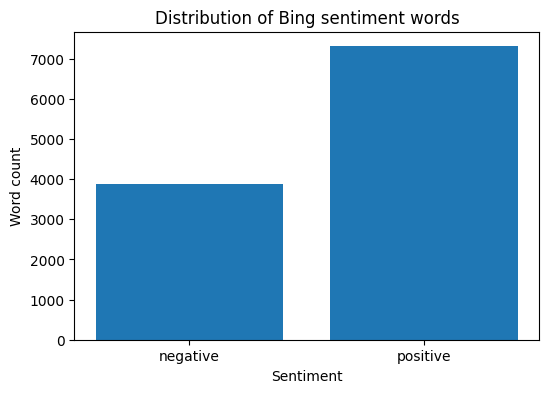

In [13]:
# count sentiment words
sentiment_counts = (
    bing_words
    .groupby("sentiment")
    .size()
    .reset_index(name="n")
)

# plot
plt.figure(figsize=(6, 4))

plt.bar(
    sentiment_counts["sentiment"],
    sentiment_counts["n"]
)

plt.title("Distribution of Bing sentiment words")
plt.xlabel("Sentiment")
plt.ylabel("Word count")

plt.show()

In [14]:
top_bing_words = (
    bing_words
    .groupby(["sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby("sentiment", group_keys=False)
    .head(10)
)

top_bing_words.head()

,sentiment,word,n
728,positive,easy,973
800,positive,great,639
853,positive,love,409
794,positive,good,361
848,positive,like,361


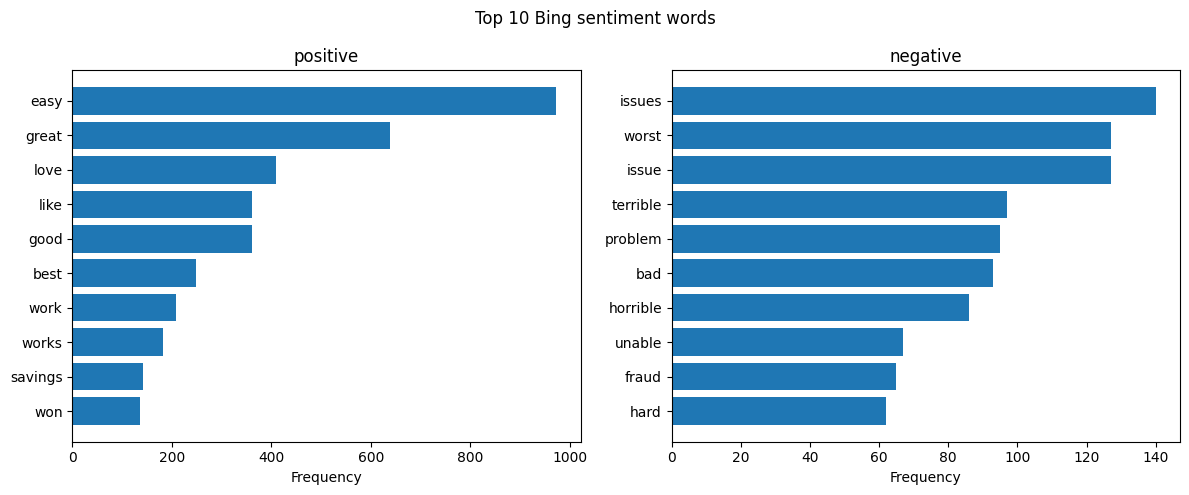

In [15]:
sentiments = top_bing_words["sentiment"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sentiments),
    figsize=(12, 5),
    sharex=False
)

if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sentiments):
    data = (
        top_bing_words[top_bing_words["sentiment"] == sentiment]
        .sort_values("n")
    )

    ax.barh(data["word"], data["n"])
    ax.set_title(sentiment)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

fig.suptitle("Top 10 Bing sentiment words")
plt.tight_layout()
plt.show()

In [16]:
bing_by_bank = (
    bing_words
    .groupby(["bank", "sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby(["bank", "sentiment"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

bing_by_bank.head()

,bank,sentiment,word,n
0,Citi,positive,easy,286
1,Marcus By Goldman Sachs,positive,easy,230
2,Bank Of America,positive,easy,181
3,Marcus By Goldman Sachs,positive,great,166
4,Wells Fargo,positive,easy,146


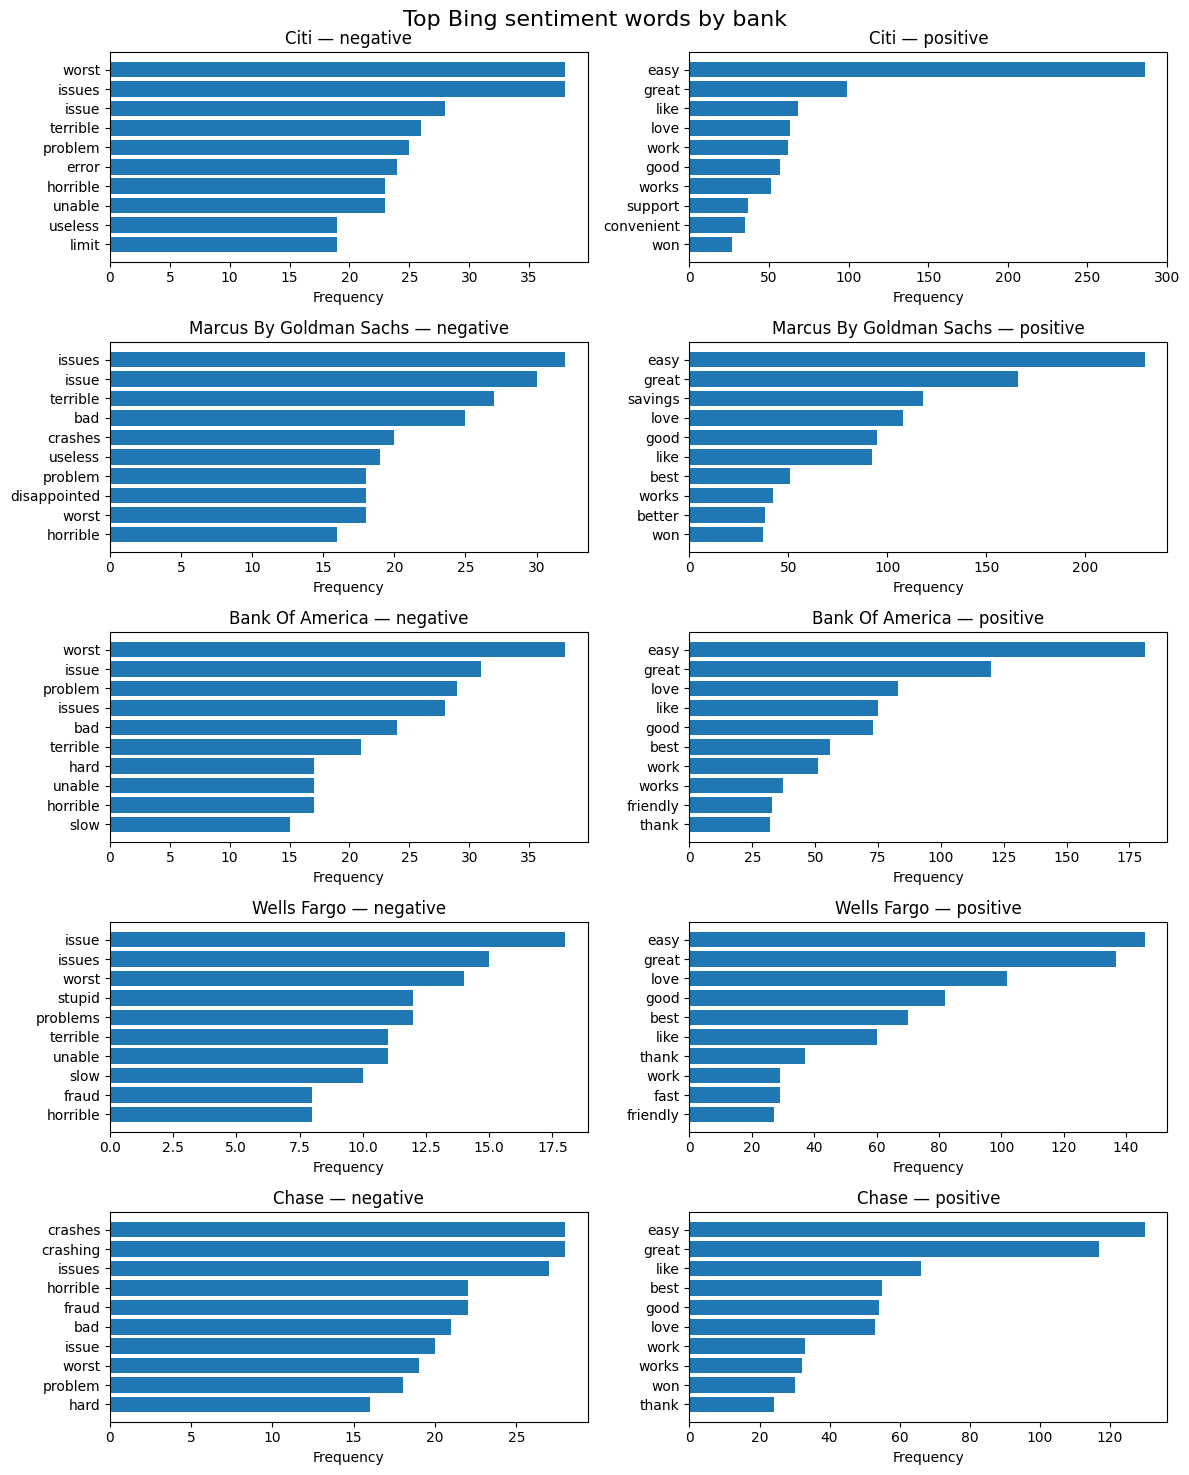

In [17]:
banks = bing_by_bank["bank"].drop_duplicates().tolist()
sentiments = ["negative", "positive"]

fig, axes = plt.subplots(
    nrows=len(banks),
    ncols=len(sentiments),
    figsize=(12, 3 * len(banks)),
    squeeze=False
)

for i, bank in enumerate(banks):
    for j, sentiment in enumerate(sentiments):
        ax = axes[i, j]

        data = (
            bing_by_bank[
                (bing_by_bank["bank"] == bank) &
                (bing_by_bank["sentiment"] == sentiment)
            ]
            .sort_values("n", ascending=True)
        )

        ax.barh(data["word"], data["n"])

        ax.set_title(f"{bank} — {sentiment}")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("")

        if data.empty:
            ax.axis("off")

fig.suptitle("Top Bing sentiment words by bank", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
# sentiment words by platform
bing_by_platform = (
    bing_words
    .groupby(["platform", "sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby(["platform", "sentiment"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

bing_by_platform.head()

,platform,sentiment,word,n
0,Android,positive,easy,670
1,Android,positive,great,350
2,iOS,positive,easy,303
3,iOS,positive,great,289
4,iOS,positive,like,219


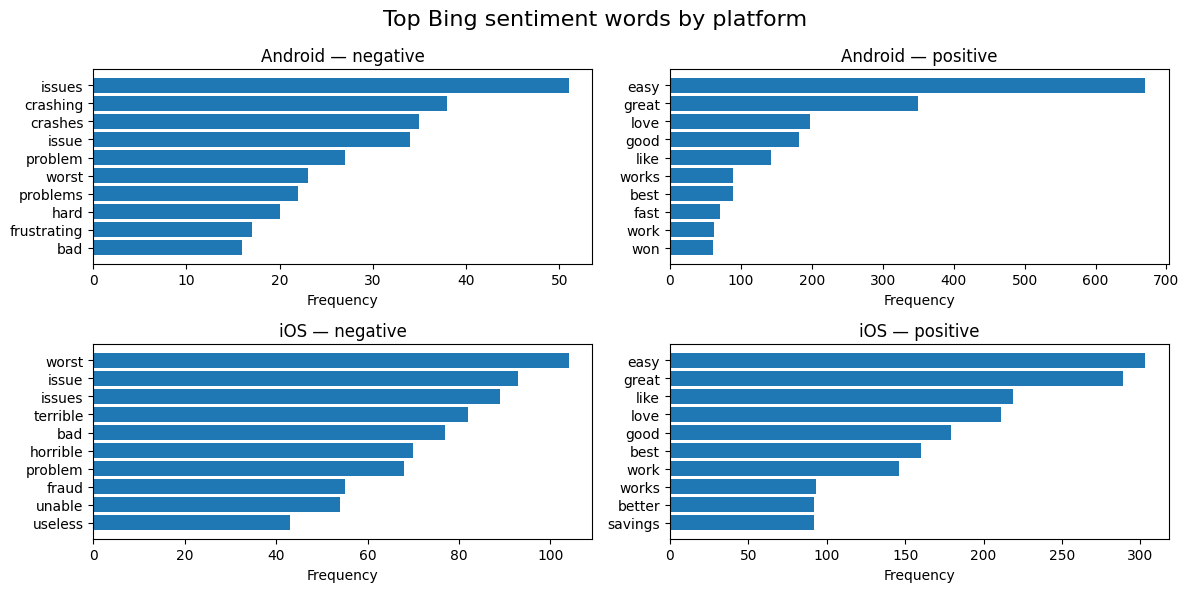

In [19]:
platforms = bing_by_platform["platform"].drop_duplicates().tolist()
sentiments = ["negative", "positive"]

fig, axes = plt.subplots(
    nrows=len(platforms),
    ncols=len(sentiments),
    figsize=(12, 3 * len(platforms)),
    squeeze=False
)

for i, platform in enumerate(platforms):
    for j, sentiment in enumerate(sentiments):
        ax = axes[i, j]

        data = (
            bing_by_platform[
                (bing_by_platform["platform"] == platform) &
                (bing_by_platform["sentiment"] == sentiment)
            ]
            .sort_values("n", ascending=True)
        )

        ax.barh(data["word"], data["n"])

        ax.set_title(f"{platform} — {sentiment}")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("")

        if data.empty:
            ax.axis("off")

fig.suptitle("Top Bing sentiment words by platform", fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
bing_sentiment_pct = (
    bing_words
    .groupby(["bank", "platform", "sentiment"])
    .size()
    .reset_index(name="n")
)

bing_sentiment_pct["pct"] = (
    bing_sentiment_pct["n"] /
    bing_sentiment_pct.groupby(["bank", "platform"])["n"].transform("sum")
)

bing_sentiment_pct.head()

,bank,platform,sentiment,n,pct
0,Bank Of America,Android,negative,163,0.183559
1,Bank Of America,Android,positive,725,0.816441
2,Bank Of America,iOS,negative,621,0.458303
3,Bank Of America,iOS,positive,734,0.541697
4,Chase,Android,negative,280,0.363636


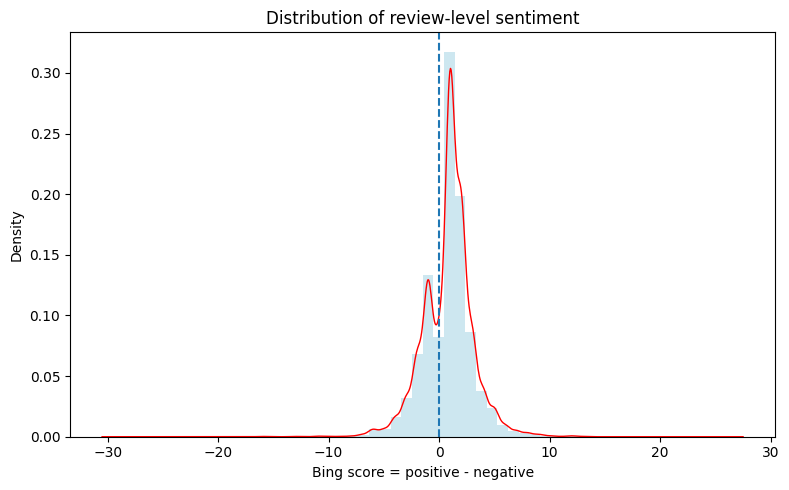

In [21]:
# Keep only finite sentiment scores
df_sent_plot = df_sent[np.isfinite(df_sent["sentiment_score"])].copy()

# Plot histogram + density curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_sent_plot["sentiment_score"],
    bins=30,
    density=True,
    color="lightblue",
    alpha=0.6
)

df_sent_plot["sentiment_score"].plot(
    kind="density",
    ax=ax,
    color="red",
    linewidth=1
)

ax.axvline(0, linestyle="--")

ax.set_title("Distribution of review-level sentiment")
ax.set_xlabel("Bing score = positive - negative")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

### Sentiment score and star ratings

/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/2471032148.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


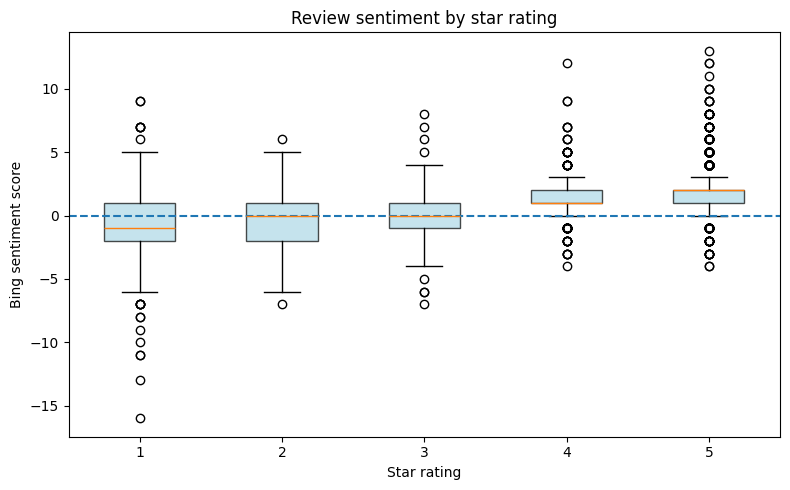

In [22]:
# Sentiment score and star ratings
# This plot shows whether the Bing sentiment score becomes more positive as star ratings increase.

rating_col = "rating"

if rating_col not in df_sent_plot.columns:
    raise KeyError(
        f"Column '{rating_col}' was not found. Available columns are: {df_sent_plot.columns.tolist()}"
    )

rating_plot = df_sent_plot.copy()
rating_plot[rating_col] = pd.to_numeric(rating_plot[rating_col], errors="coerce")
rating_plot["sentiment_score"] = pd.to_numeric(rating_plot["sentiment_score"], errors="coerce")

rating_plot = rating_plot.dropna(subset=[rating_col, "sentiment_score"])
rating_plot = rating_plot[np.isfinite(rating_plot["sentiment_score"])]

ratings = sorted(rating_plot[rating_col].unique())
box_data = [
    rating_plot.loc[rating_plot[rating_col] == rating, "sentiment_score"]
    for rating in ratings
]

rating_labels = [
    str(int(rating)) if float(rating).is_integer() else str(rating)
    for rating in ratings
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    box_data,
    labels=rating_labels,
    patch_artist=True
)

for patch in box["boxes"]:
    patch.set_facecolor("lightblue")
    patch.set_alpha(0.7)

ax.axhline(0, linestyle="--")

ax.set_title("Review sentiment by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Bing sentiment score")

plt.tight_layout()
plt.show()

### AFINN

In [23]:
# Load AFINN sentiment lexicon
afinn = load_afinn_lexicon()

afinn.head()

,word,value
0,abandon,-2
1,abandoned,-2
2,abandons,-2
3,abducted,-2
4,abduction,-2


In [24]:
# Join AFINN scores to the tokenized review words
afinn_words = reviews_after_sw.merge(
    afinn,
    on="word",
    how="inner"
)

print("AFINN words:", len(afinn_words))
print("Bing words:", len(bing_words))

afinn_words.head()

AFINN words: 9659
Bing words: 11194


,tokens,bank,platform,rating,date,raw_text,review_id,word,value
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,-3
1,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,-3
2,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,benefit,2
3,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,good,3
4,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,easy,1


In [25]:
# Most frequent AFINN-scored words
top_afinn_words = (
    afinn_words
    .groupby(["word", "value"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_afinn_words

,word,value,n
0,easy,1,973
1,great,3,639
2,love,3,409
3,like,2,361
4,good,3,361
5,best,3,249
6,pay,-1,200
7,help,2,163
8,want,1,137
9,won,3,136


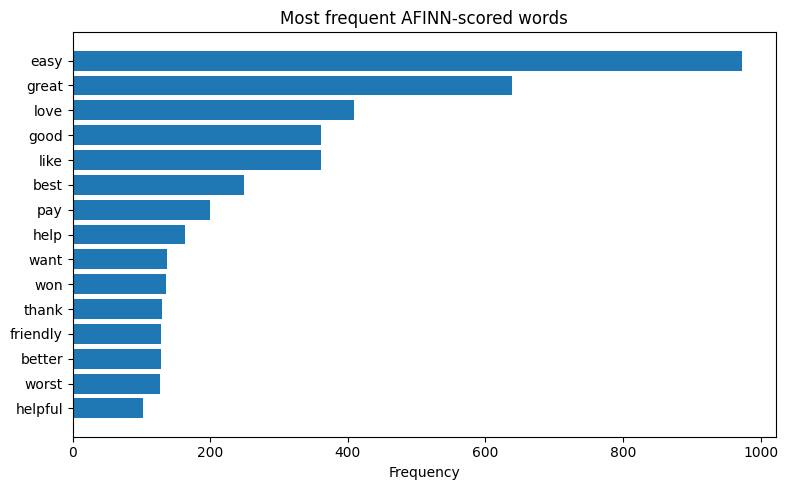

In [26]:
# Plot most frequent AFINN-scored words
plot_data = top_afinn_words.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(plot_data["word"], plot_data["n"])

ax.set_title("Most frequent AFINN-scored words")
ax.set_xlabel("Frequency")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Review-level AFINN sentiment

In [27]:
# Create the total AFINN score for each review and the mean AFINN score per review
afinn_review = (
    afinn_words
    .groupby(["bank", "platform", "review_id"])
    .agg(
        afinn_sum=("value", "sum"),
        afinn_mean=("value", "mean"),
        n_afinn=("value", "size")
    )
    .reset_index()
)

# Join review-level AFINN scores back to the review-level dataset
df_afinn = df_english.copy()
df_afinn["rating"] = pd.to_numeric(df_afinn["rating"], errors="coerce")

df_afinn = df_afinn.merge(
    afinn_review,
    on=["bank", "platform", "review_id"],
    how="left"
)

df_afinn.head()

,tokens,bank,platform,rating,date,raw_text,review_id,afinn_sum,afinn_mean,n_afinn
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,-6.0,-3.000000,2.0
1,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,5.0,2.500000,2.0
2,"['easy', 'use', 'year', 'old', 'woman', 'like'...",Bank Of America,iOS,5,2025-12-28 10:27:09-07:00,App The app is easy to use for a 63-year-old w...,2,9.0,1.800000,5.0
3,"['white', 'screen', 'use', 'face', 'id', 'log'...",Bank Of America,iOS,1,2025-12-27 20:53:27-07:00,"White screen If you use Face ID, after a while...",3,-3.0,-3.000000,1.0
4,"['inbox', 'alert', 'error', 'week', 've', 'una...",Bank Of America,iOS,1,2025-12-27 16:51:26-07:00,Inbox Alert Error For over a week I’ve been un...,4,-7.0,-1.166667,6.0


In [28]:
# How many reviews received an AFINN score?
afinn_scoring_summary = pd.DataFrame({
    "total_reviews": [len(df_afinn)],
    "scored_reviews": [df_afinn["afinn_sum"].notna().sum()],
    "pct_scored": [100 * df_afinn["afinn_sum"].notna().mean()]
})

afinn_scoring_summary

,total_reviews,scored_reviews,pct_scored
0,4517,3832,84.835068


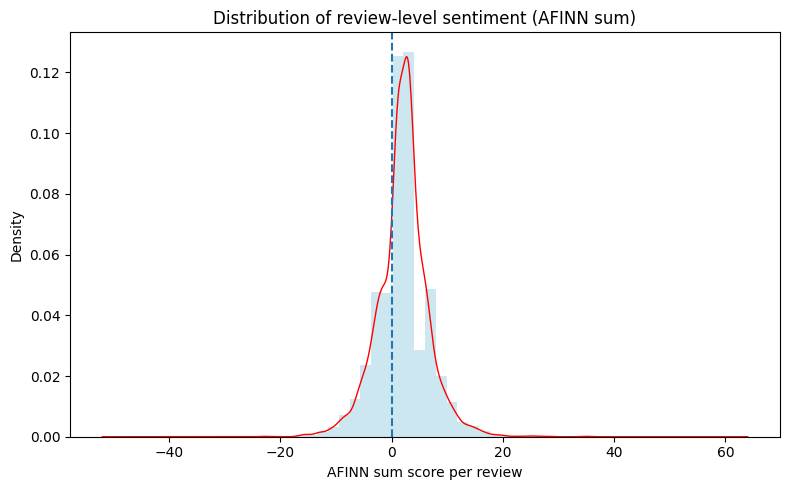

In [29]:
# Distribution of review-level AFINN sentiment
df_afinn_plot = df_afinn[np.isfinite(df_afinn["afinn_sum"])].copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_afinn_plot["afinn_sum"],
    bins=30,
    density=True,
    color="lightblue",
    alpha=0.6
)

df_afinn_plot["afinn_sum"].plot(
    kind="density",
    ax=ax,
    color="red",
    linewidth=1
)

ax.axvline(0, linestyle="--")

ax.set_title("Distribution of review-level sentiment (AFINN sum)")
ax.set_xlabel("AFINN sum score per review")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

### AFINN sentiment by bank and platform

In [30]:
# How tone varies by bank and platform
afinn_bank_platform = (
    df_afinn
    .groupby(["bank", "platform"])
    .agg(
        mean_sum=("afinn_sum", "mean"),
        mean_mean=("afinn_mean", "mean"),
        n_reviews=("review_id", "size"),
        n_scored=("afinn_sum", lambda x: x.notna().sum())
    )
    .reset_index()
)

afinn_bank_platform

,bank,platform,mean_sum,mean_mean,n_reviews,n_scored
0,Bank Of America,Android,2.762626,1.585835,458,396
1,Bank Of America,iOS,1.231383,0.524831,446,376
2,Chase,Android,1.942197,1.310460,474,346
3,Chase,iOS,1.306233,0.603432,420,369
4,Citi,Android,2.612676,1.519799,473,426
5,Citi,iOS,-0.566234,-0.216948,456,385
6,Marcus By Goldman Sachs,Android,2.452055,1.254515,526,438
7,Marcus By Goldman Sachs,iOS,3.026190,0.937953,481,420
8,Wells Fargo,Android,2.179894,1.426184,456,378
9,Wells Fargo,iOS,3.469799,1.443535,327,298


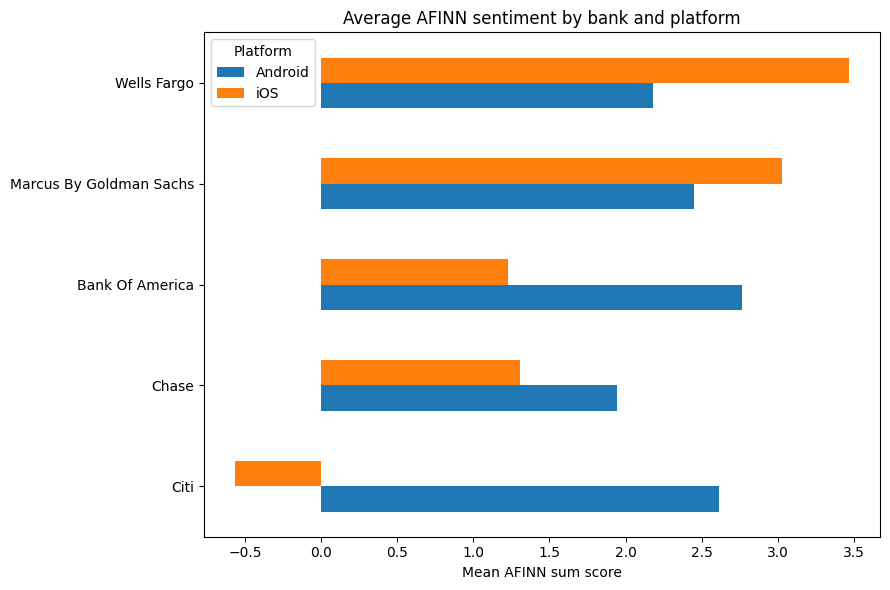

In [31]:
# Plot average AFINN sentiment by bank and platform
pivot_plot = afinn_bank_platform.pivot(
    index="bank",
    columns="platform",
    values="mean_sum"
)

# Order banks by the average AFINN score across platforms
bank_order = pivot_plot.mean(axis=1).sort_values().index
pivot_plot = pivot_plot.loc[bank_order]

fig, ax = plt.subplots(figsize=(9, 6))

pivot_plot.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Average AFINN sentiment by bank and platform")
ax.set_xlabel("Mean AFINN sum score")
ax.set_ylabel("")
ax.legend(title="Platform")

plt.tight_layout()
plt.show()

### Top AFINN words by sentiment score

In [32]:
# Top AFINN sentiment words by score
top_afinn_by_score = (
    afinn_words
    .groupby(["value", "word"])
    .size()
    .reset_index(name="n")
    .sort_values(["value", "n"], ascending=[True, False])
    .groupby("value", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

top_afinn_by_score

,value,word,n
0,-4,fraud,65
1,-4,fraudulent,9
2,-4,hell,3
3,-4,damn,2
4,-4,wtf,2
...,...,...,...
74,4,wins,2
75,4,brilliant,1
76,5,outstanding,19
77,5,superb,4


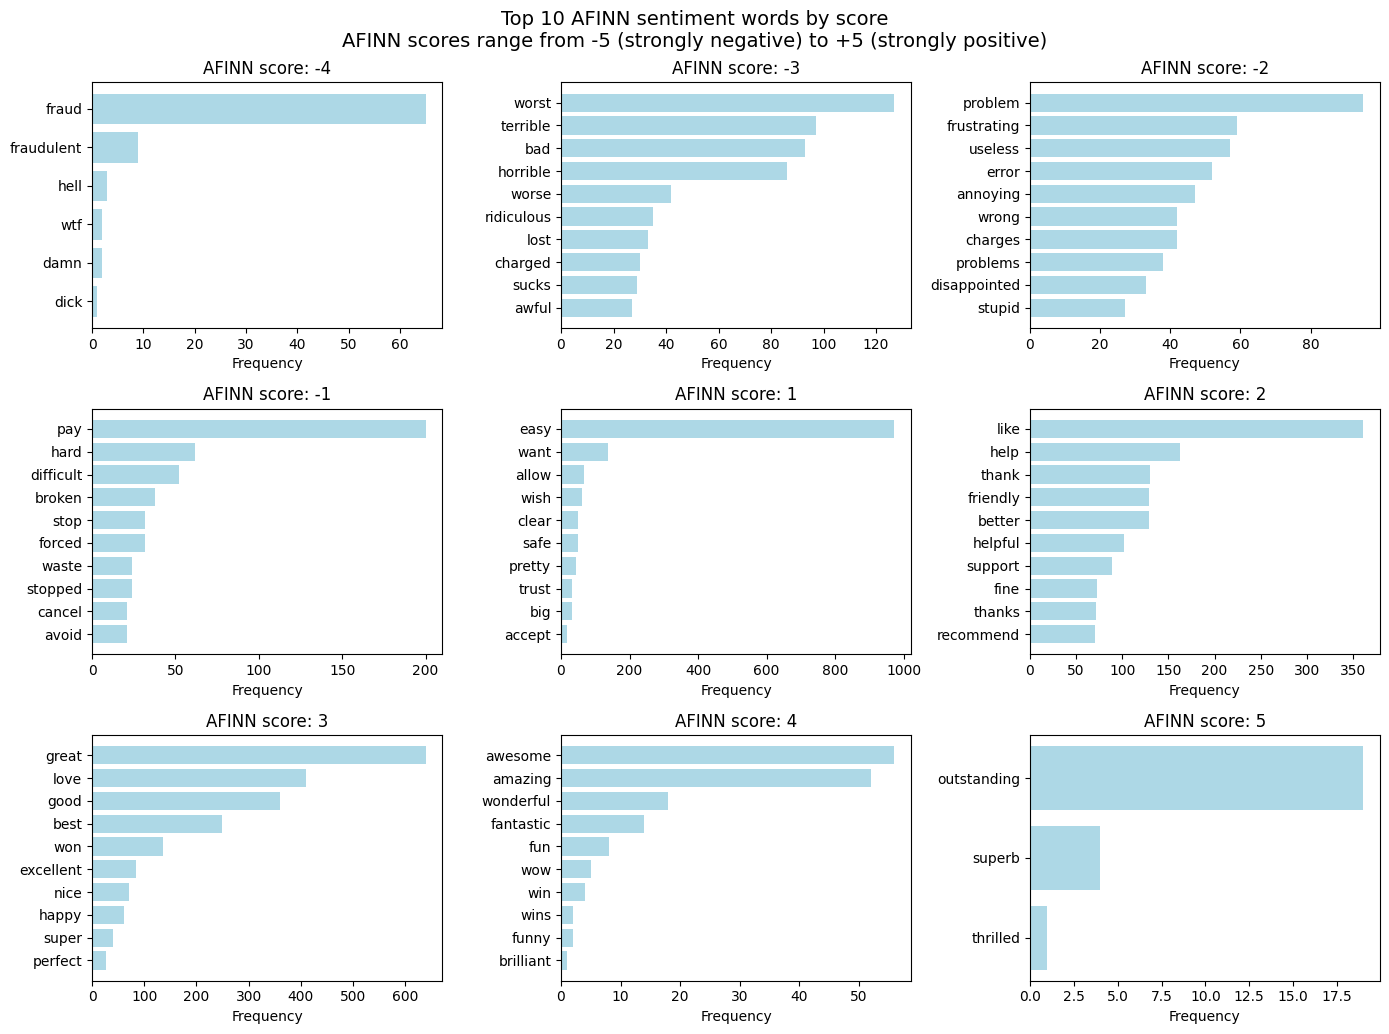

In [33]:
# Plot top AFINN words by score
values = sorted(top_afinn_by_score["value"].dropna().unique())
ncols = 3
nrows = math.ceil(len(values) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 3.5 * nrows),
    squeeze=False
)

axes_flat = axes.flatten()

for ax, value in zip(axes_flat, values):
    data = (
        top_afinn_by_score[top_afinn_by_score["value"] == value]
        .sort_values("n", ascending=True)
    )

    ax.barh(data["word"], data["n"], color="lightblue")
    ax.set_title(f"AFINN score: {int(value)}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

for ax in axes_flat[len(values):]:
    ax.axis("off")

fig.suptitle(
    "Top 10 AFINN sentiment words by score\nAFINN scores range from -5 (strongly negative) to +5 (strongly positive)",
    fontsize=14
)

plt.tight_layout()
plt.show()

### AFINN sentiment and star ratings

/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/2826671166.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


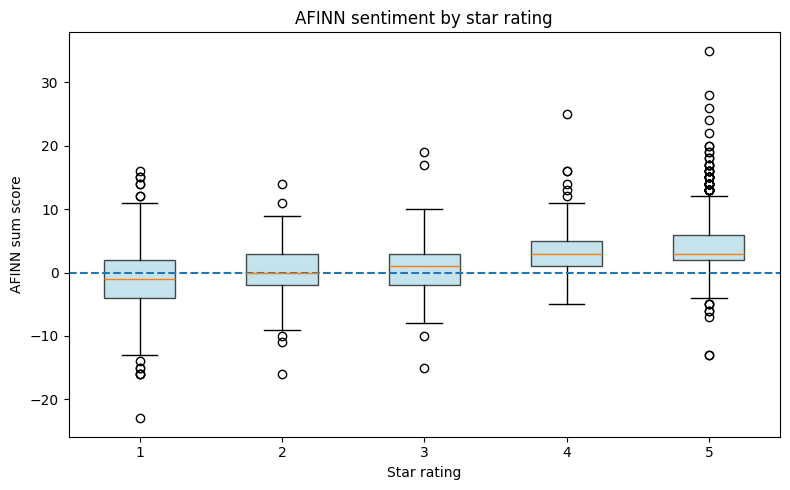

In [34]:
# AFINN sentiment by star rating
df_afinn_rating_plot = df_afinn.copy()
df_afinn_rating_plot["rating"] = pd.to_numeric(df_afinn_rating_plot["rating"], errors="coerce")
df_afinn_rating_plot["afinn_sum"] = pd.to_numeric(df_afinn_rating_plot["afinn_sum"], errors="coerce")

df_afinn_rating_plot = df_afinn_rating_plot.dropna(subset=["rating", "afinn_sum"])
df_afinn_rating_plot = df_afinn_rating_plot[np.isfinite(df_afinn_rating_plot["afinn_sum"])]

ratings = sorted(df_afinn_rating_plot["rating"].unique())
box_data = [
    df_afinn_rating_plot.loc[df_afinn_rating_plot["rating"] == rating, "afinn_sum"]
    for rating in ratings
]

rating_labels = [
    str(int(rating)) if float(rating).is_integer() else str(rating)
    for rating in ratings
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    box_data,
    labels=rating_labels,
    patch_artist=True
)

for patch in box["boxes"]:
    patch.set_facecolor("lightblue")
    patch.set_alpha(0.7)

ax.axhline(0, linestyle="--")

ax.set_title("AFINN sentiment by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("AFINN sum score")

plt.tight_layout()
plt.show()

In [35]:
# Pearson correlation between star rating and AFINN sum score
cor_data = df_afinn_rating_plot[["rating", "afinn_sum"]].dropna()

if len(cor_data) >= 3:
    r, p_value = pearsonr(cor_data["rating"], cor_data["afinn_sum"])
    n = len(cor_data)

    # Approximate 95% confidence interval using Fisher z-transformation
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.96
    ci_low, ci_high = np.tanh([z - z_crit * se, z + z_crit * se])

    print("Pearson correlation test")
    print(f"n = {n}")
    print(f"correlation = {r:.4f}")
    print(f"p-value = {p_value:.4g}")
    print(f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")
else:
    print("Not enough complete observations for correlation test.")

Pearson correlation test
n = 3832
correlation = 0.5282
p-value = 1.975e-274
95% CI = [0.5050, 0.5507]


### NRC

The NRC lexicon assigns words to several emotion categories. One word can belong to more than one category, so the join is expected to create multiple rows for some words.

In [36]:
# Load NRC emotion lexicon
# The loading function is defined at the top of the notebook.
nrc = load_nrc_lexicon()

nrc.head()

,word,sentiment
19,abacus,trust
23,abandon,fear
25,abandon,negative
27,abandon,sadness
30,abandoned,anger


In [37]:
# Join NRC categories to the tokenized review words
# This is a many-to-many relationship because one word can match several NRC categories.

nrc_words = reviews_after_sw.merge(
    nrc,
    on="word",
    how="inner"
)

print("NRC words:", len(nrc_words))
print("Total tokens after stopword removal:", len(reviews_after_sw))

nrc_words.head()

NRC words: 28423
Total tokens after stopword removal: 55215


,tokens,bank,platform,rating,date,raw_text,review_id,word,sentiment
0,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,anger
1,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,disgust
2,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,fear
3,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,negative
4,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,anger


In [38]:
# Overview of NRC emotion category counts
nrc_counts = (
    nrc_words
    .groupby("sentiment")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

nrc_counts

,sentiment,n
0,positive,6852
1,trust,5160
2,negative,3433
3,anticipation,3068
4,joy,2858
5,anger,1690
6,sadness,1564
7,fear,1504
8,surprise,1400
9,disgust,894


In [39]:
# NRC token coverage
nrc_coverage = pd.DataFrame({
    "total_tokens": [len(reviews_after_sw)],
    "nrc_tokens": [len(nrc_words)],
    "pct_covered": [100 * len(nrc_words) / len(reviews_after_sw)]
})

nrc_coverage

,total_tokens,nrc_tokens,pct_covered
0,55215,28423,51.476954


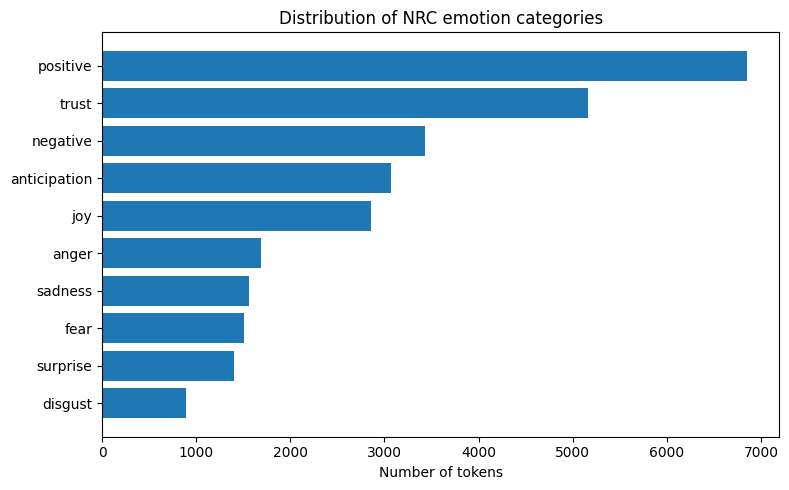

In [40]:
# Plot distribution of NRC emotion categories
plot_data = nrc_counts.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(plot_data["sentiment"], plot_data["n"])

ax.set_title("Distribution of NRC emotion categories")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### NRC emotion composition by bank

In [41]:
# NRC emotion by bank
nrc_by_bank = (
    nrc_words
    .groupby(["bank", "sentiment"])
    .size()
    .reset_index(name="n")
)

nrc_by_bank["pct"] = (
    nrc_by_bank["n"] /
    nrc_by_bank.groupby("bank")["n"].transform("sum")
)

nrc_by_bank

,bank,sentiment,n,pct
0,Bank Of America,anger,274,0.052071
1,Bank Of America,anticipation,590,0.112125
2,Bank Of America,disgust,158,0.030027
3,Bank Of America,fear,316,0.060053
4,Bank Of America,joy,572,0.108704
5,Bank Of America,negative,595,0.113075
6,Bank Of America,positive,1266,0.240593
7,Bank Of America,sadness,321,0.061003
8,Bank Of America,surprise,250,0.047510
9,Bank Of America,trust,920,0.174838


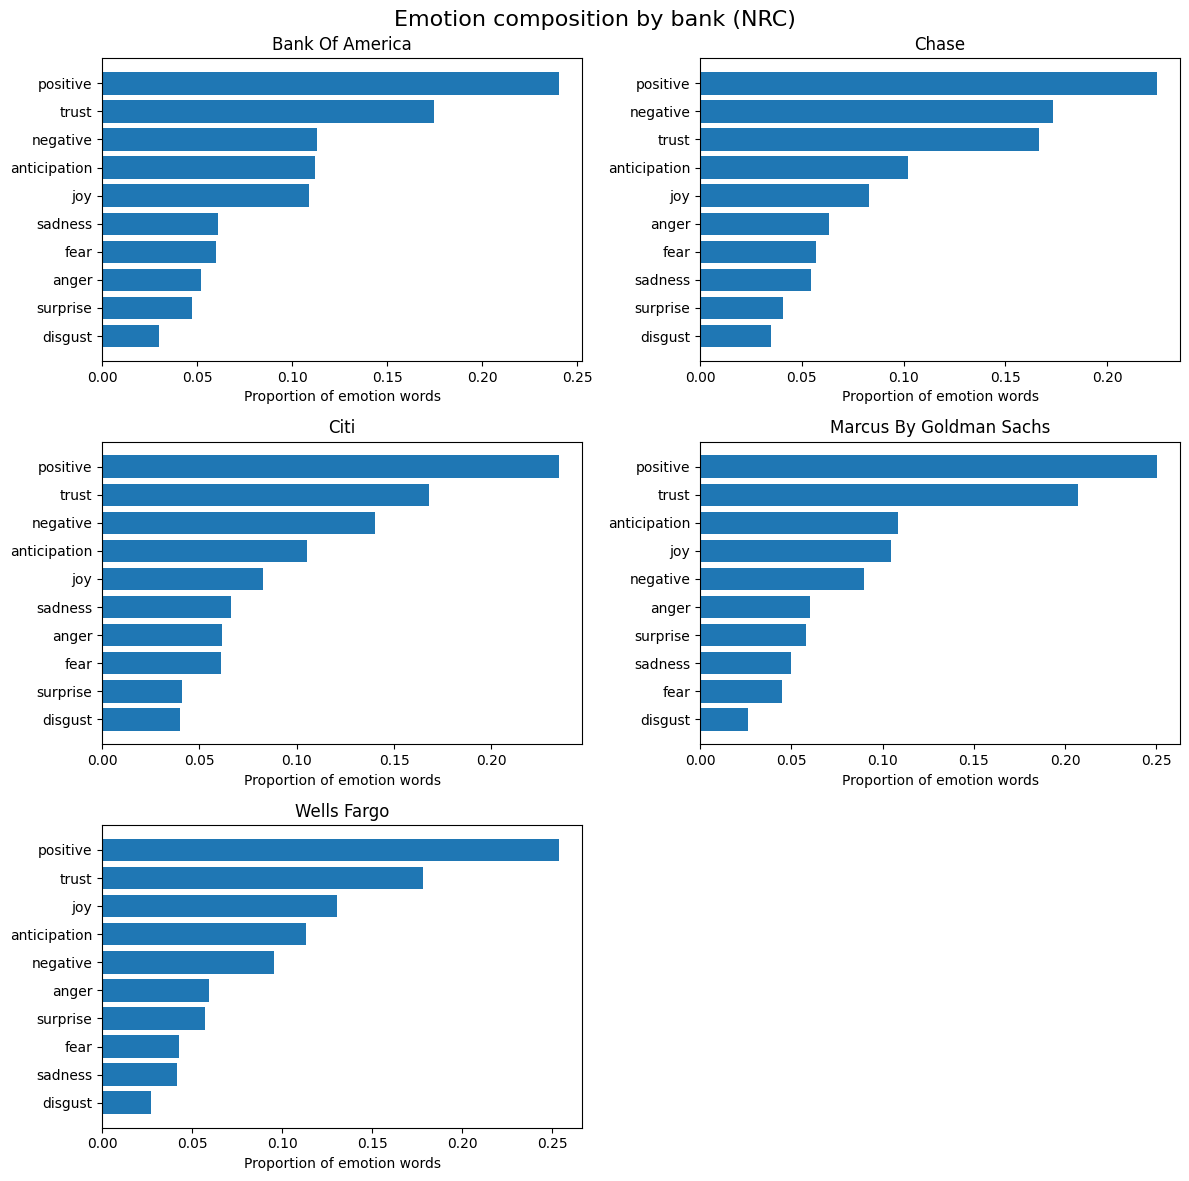

In [42]:
# Plot emotion composition by bank
banks = sorted(nrc_by_bank["bank"].unique())
n_cols = 2
n_rows = int(np.ceil(len(banks) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(12, 4 * n_rows),
    squeeze=False
)

for i, bank in enumerate(banks):
    ax = axes[i // n_cols, i % n_cols]
    data = (
        nrc_by_bank[nrc_by_bank["bank"] == bank]
        .sort_values("pct", ascending=True)
    )

    ax.barh(data["sentiment"], data["pct"])
    ax.set_title(bank)
    ax.set_xlabel("Proportion of emotion words")
    ax.set_ylabel("")

# Hide unused subplot panels, if any
for j in range(len(banks), n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")

fig.suptitle("Emotion composition by bank (NRC)", fontsize=16)
plt.tight_layout()
plt.show()

### NRC emotion composition by platform

In [43]:
# NRC emotion by platform
nrc_by_platform = (
    nrc_words
    .groupby(["platform", "sentiment"])
    .size()
    .reset_index(name="n")
)

nrc_by_platform["pct"] = (
    nrc_by_platform["n"] /
    nrc_by_platform.groupby("platform")["n"].transform("sum")
)

nrc_by_platform

,platform,sentiment,n,pct
0,Android,anger,427,0.046887
1,Android,anticipation,1045,0.114747
2,Android,disgust,187,0.020534
3,Android,fear,358,0.039310
4,Android,joy,1120,0.122982
5,Android,negative,879,0.096519
6,Android,positive,2460,0.270122
7,Android,sadness,377,0.041397
8,Android,surprise,497,0.054573
9,Android,trust,1757,0.192929


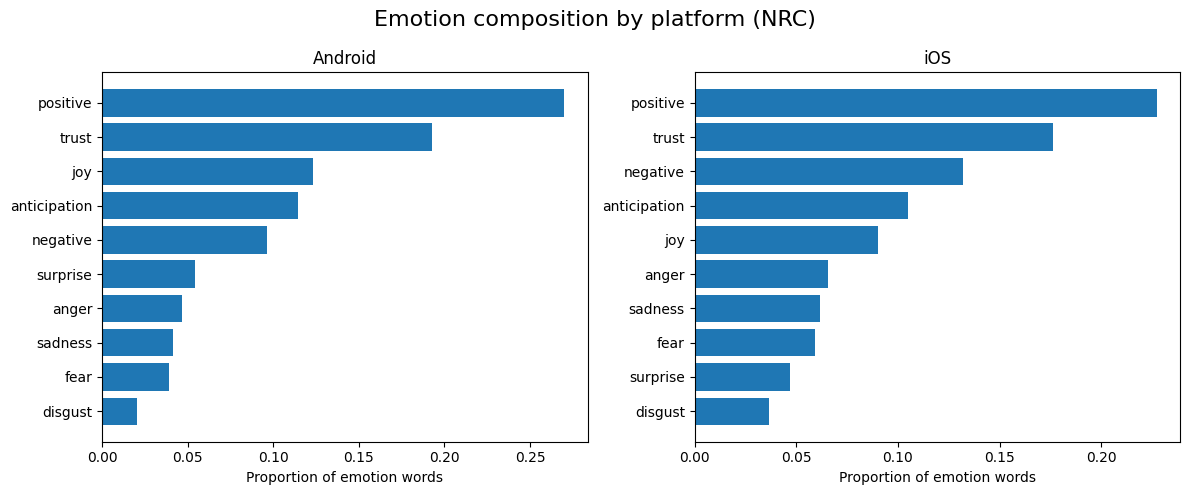

In [44]:
# Plot emotion composition by platform
platforms = sorted(nrc_by_platform["platform"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(6 * len(platforms), 5),
    squeeze=False
)

for i, platform in enumerate(platforms):
    ax = axes[0, i]
    data = (
        nrc_by_platform[nrc_by_platform["platform"] == platform]
        .sort_values("pct", ascending=True)
    )

    ax.barh(data["sentiment"], data["pct"])
    ax.set_title(platform)
    ax.set_xlabel("Proportion of emotion words")
    ax.set_ylabel("")

fig.suptitle("Emotion composition by platform (NRC)", fontsize=16)
plt.tight_layout()
plt.show()

### Bigrams

In [45]:
# Create bigrams from the original review text.
# This keeps review-level metadata such as bank, platform, review_id, and rating.
# Negation words are kept because they are important for interpreting sentiment.

# Use the existing stopword list, but do not remove negators.
custom_stop_words_bigram = set(custom_stop_words["word"]) - NEGATORS

bigrams = create_bigrams_dataframe(
    df=df_english,
    stop_words=custom_stop_words_bigram,
    text_col="raw_text"
)

bigrams.head()

,tokens,bank,platform,rating,date,raw_text,review_id,word1,word2
3,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,t,load
16,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,horrible,customer
17,"['horrible', 't', 'load', 'bc', 'require', 'di...",Bank Of America,iOS,1,2025-12-28 13:28:49-07:00,Horrible. I can’t load the banking app bc it r...,0,customer,service
38,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,america,application
39,"['america', 'application', 'benefit', 'america...",Bank Of America,iOS,5,2025-12-28 11:48:52-07:00,Bank Of America Application Benefit Bank Of Am...,1,application,benefit


In [46]:
# Count most frequent bigrams
bigram_counts = (
    bigrams
    .groupby(["word1", "word2"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

bigram_counts.head(20)

,word1,word2,n
0,customer,service,250
1,don,t,182
2,wells,fargo,166
3,credit,card,154
4,doesn,t,130
5,user,friendly,84
6,does,not,82
7,no,longer,72
8,won,t,70
9,savings,account,64


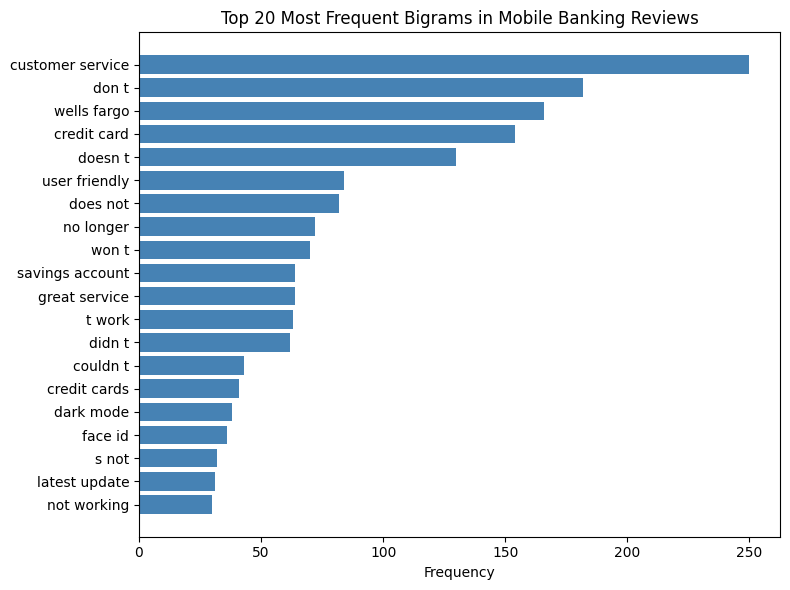

In [47]:
# Plot top 20 most frequent bigrams
top20_bigrams = bigram_counts.head(20).copy()
top20_bigrams["bigram"] = top20_bigrams["word1"] + " " + top20_bigrams["word2"]

plot_data = top20_bigrams.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(plot_data["bigram"], plot_data["n"], color="steelblue")

ax.set_title("Top 20 Most Frequent Bigrams in Mobile Banking Reviews")
ax.set_xlabel("Frequency")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Quantifying negation effect

In [48]:
# Identify bigrams where the first word is a negator and the second word has an AFINN score.
# The negated value reverses the original AFINN score.

negated_afinn = (
    bigrams[bigrams["word1"].isin(NEGATORS)]
    .merge(
        afinn,
        left_on="word2",
        right_on="word",
        how="inner"
    )
    .copy()
)

negated_afinn["negated_value"] = -negated_afinn["value"]

negation_by_bigram = (
    negated_afinn
    .groupby(["word1", "word2"])
    .agg(
        original_value=("value", "mean"),
        negated_value=("negated_value", "mean"),
        n_occurrences=("word2", "size")
    )
    .reset_index()
    .sort_values("n_occurrences", ascending=False)
    .reset_index(drop=True)
)

negation_by_bigram.head(20)

,word1,word2,original_value,negated_value,n_occurrences
0,not,allow,1.0,-1.0,20
1,not,recommend,2.0,-2.0,15
2,no,problems,-2.0,2.0,10
3,not,happy,3.0,-3.0,10
4,no,matter,1.0,-1.0,9
5,not,worth,2.0,-2.0,8
6,don't,like,2.0,-2.0,8
7,not,good,3.0,-3.0,8
8,no,help,2.0,-2.0,8
9,not,want,1.0,-1.0,7


In [49]:
# Quantify the size of the negation correction by star rating.

negated_afinn["rating"] = pd.to_numeric(negated_afinn["rating"], errors="coerce")
negated_afinn_rating = negated_afinn.dropna(subset=["rating"]).copy()

neg_by_rating = (
    negated_afinn_rating
    .groupby("rating")
    .agg(
        total_negation_shift=("negated_value", "sum"),
        mean_negation_shift=("negated_value", "mean"),
        n_negated_bigrams=("negated_value", "size")
    )
    .reset_index()
)

reviews_per_rating = (
    df_english
    .assign(rating=pd.to_numeric(df_english["rating"], errors="coerce"))
    .dropna(subset=["rating"])
    .groupby("rating")
    .size()
    .reset_index(name="n_reviews")
)

negation_by_rating_norm = neg_by_rating.merge(
    reviews_per_rating,
    on="rating",
    how="left"
)

negation_by_rating_norm["negation_shift_per_review"] = (
    negation_by_rating_norm["total_negation_shift"] /
    negation_by_rating_norm["n_reviews"]
)

negation_by_rating_norm["negated_bigrams_per_review"] = (
    negation_by_rating_norm["n_negated_bigrams"] /
    negation_by_rating_norm["n_reviews"]
)

negation_by_rating_norm

,rating,total_negation_shift,mean_negation_shift,n_negated_bigrams,n_reviews,negation_shift_per_review,negated_bigrams_per_review
0,1,-256,-1.292929,198,1467,-0.174506,0.134969
1,2,-59,-1.475000,40,268,-0.220149,0.149254
2,3,-25,-1.470588,17,221,-0.113122,0.076923
3,4,-12,-0.705882,17,287,-0.041812,0.059233
4,5,36,0.734694,49,2274,0.015831,0.021548


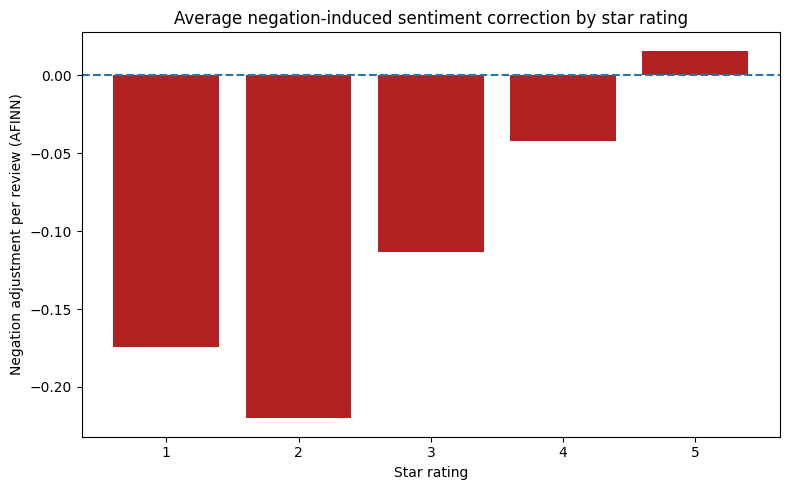

In [50]:
# Plot average negation-induced sentiment correction by star rating
plot_data = negation_by_rating_norm.sort_values("rating").copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    plot_data["rating"].astype(str),
    plot_data["negation_shift_per_review"],
    color="firebrick"
)

ax.axhline(0, linestyle="--")

ax.set_title("Average negation-induced sentiment correction by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Negation adjustment per review (AFINN)")

plt.tight_layout()
plt.show()

### 7. Compare unigram vs bigram with negators

This section compares the classic review-level AFINN score based on unigrams with a negation-aware version that adjusts scores for negator + AFINN-word bigrams.

In [51]:
# Classic AFINN per review (unigram)
# This is the standard AFINN score without a negation adjustment.

afinn_classic_source = afinn_words.copy()
afinn_classic_source["rating"] = pd.to_numeric(afinn_classic_source["rating"], errors="coerce")

afinn_classic = (
    afinn_classic_source
    .groupby(["review_id", "bank", "platform", "rating"], dropna=False)
    .agg(
        afinn_sum=("value", "sum")
    )
    .reset_index()
)

afinn_classic.head()

,review_id,bank,platform,rating,afinn_sum
0,0,Bank Of America,iOS,1,-6
1,1,Bank Of America,iOS,5,5
2,2,Bank Of America,iOS,5,9
3,3,Bank Of America,iOS,1,-3
4,4,Bank Of America,iOS,1,-7


In [52]:
# Bigram-based negation adjustment per review
# This uses negator + AFINN-word bigrams created in the previous negation section.

negation_review = (
    negated_afinn
    .groupby("review_id", dropna=False)
    .agg(
        negated_sum=("negated_value", "sum")
    )
    .reset_index()
)

negation_review.head()

,review_id,negated_sum
0,4,-2
1,12,-2
2,15,-2
3,17,-2
4,21,-1


In [53]:
# Combine classic and negation-aware AFINN scores

sentiment_compare = afinn_classic.merge(
    negation_review,
    on="review_id",
    how="left"
)

sentiment_compare["negated_sum"] = sentiment_compare["negated_sum"].fillna(0)

# Negation-aware AFINN score = classic AFINN score + negation adjustment
sentiment_compare["afinn_negation"] = (
    sentiment_compare["afinn_sum"] + sentiment_compare["negated_sum"]
)

sentiment_compare["sentiment_diff"] = (
    sentiment_compare["afinn_negation"] - sentiment_compare["afinn_sum"]
)

sentiment_compare.head()

,review_id,bank,platform,rating,afinn_sum,negated_sum,afinn_negation,sentiment_diff
0,0,Bank Of America,iOS,1,-6,0.0,-6.0,0.0
1,1,Bank Of America,iOS,5,5,0.0,5.0,0.0
2,2,Bank Of America,iOS,5,9,0.0,9.0,0.0
3,3,Bank Of America,iOS,1,-3,0.0,-3.0,0.0
4,4,Bank Of America,iOS,1,-7,-2.0,-9.0,-2.0


In [54]:
# Mean classic and negation-aware AFINN sentiment by star rating

afinn_sentiment_stars = (
    sentiment_compare
    .dropna(subset=["rating"])
    .groupby("rating", dropna=False)
    .agg(
        overall_sentiment=("afinn_sum", "mean"),
        overall_sentiment_negaware=("afinn_negation", "mean"),
        n_reviews=("review_id", "size")
    )
    .reset_index()
    .sort_values("rating")
)

afinn_sentiment_stars["Stars"] = afinn_sentiment_stars["rating"].apply(
    lambda x: str(int(x)) if pd.notna(x) and float(x).is_integer() else str(x)
)

afinn_sentiment_stars

,rating,overall_sentiment,overall_sentiment_negaware,n_reviews,Stars
0,1,-1.266493,-1.488715,1152,1
1,2,0.146341,-0.141463,205,2
2,3,0.852941,0.705882,170,3
3,4,3.298246,3.245614,228,4
4,5,4.015888,4.032258,2077,5


In [55]:
# Prepare data for plotting classic vs negation-aware AFINN sentiment

afinn_sentiment_comparison = afinn_sentiment_stars.melt(
    id_vars=["Stars", "rating"],
    value_vars=["overall_sentiment", "overall_sentiment_negaware"],
    var_name="type",
    value_name="score"
)

afinn_sentiment_comparison["type"] = afinn_sentiment_comparison["type"].replace({
    "overall_sentiment": "Classic (no negation)",
    "overall_sentiment_negaware": "Negation-aware"
})

afinn_sentiment_comparison.head()

,Stars,rating,type,score
0,1,1,Classic (no negation),-1.266493
1,2,2,Classic (no negation),0.146341
2,3,3,Classic (no negation),0.852941
3,4,4,Classic (no negation),3.298246
4,5,5,Classic (no negation),4.015888


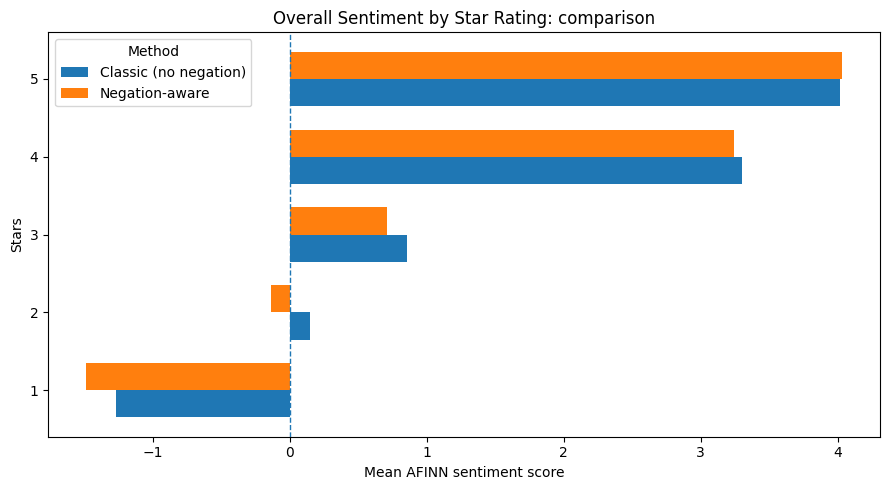

In [56]:
# Plot overall sentiment by star rating: classic vs negation-aware

star_order = afinn_sentiment_stars.sort_values("rating")["Stars"].tolist()
plot_data = (
    afinn_sentiment_comparison
    .pivot(index="Stars", columns="type", values="score")
    .reindex(star_order)
)

ax = plot_data.plot(
    kind="barh",
    figsize=(9, 5),
    width=0.7
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Overall Sentiment by Star Rating: comparison")
ax.set_xlabel("Mean AFINN sentiment score")
ax.set_ylabel("Stars")
ax.legend(title="Method")

plt.tight_layout()
plt.show()

### 8. Evaluation

This section uses statistical tests to check whether AFINN sentiment differs between platforms and whether the negation-aware version improves alignment with star ratings. The tests use AFINN score per review.

In [57]:
# Platform comparison using a Mann-Whitney U test
# This is the Python equivalent of a two-sample Wilcoxon rank-sum test.

platform_test_data = df_afinn[["platform", "afinn_sum"]].dropna().copy()
platforms = sorted(platform_test_data["platform"].unique())

if len(platforms) == 2:
    group_1 = platform_test_data.loc[platform_test_data["platform"] == platforms[0], "afinn_sum"]
    group_2 = platform_test_data.loc[platform_test_data["platform"] == platforms[1], "afinn_sum"]

    wilcox_result = mannwhitneyu(
        group_1,
        group_2,
        alternative="two-sided"
    )

    print("Wilcoxon rank-sum / Mann-Whitney U test")
    print(f"Platforms compared: {platforms[0]} vs {platforms[1]}")
    print(f"U statistic = {wilcox_result.statistic:.4f}")
    print(f"p-value = {wilcox_result.pvalue:.4g}")
else:
    print(f"Expected exactly 2 platforms, but found: {platforms}")

Wilcoxon rank-sum / Mann-Whitney U test
Platforms compared: Android vs iOS
U statistic = 2011875.5000
p-value = 1.537e-07


In [58]:
# Correlation comparison: classic vs negation-aware AFINN

cor_classic = sentiment_compare[["rating", "afinn_sum"]].dropna().corr().iloc[0, 1]
cor_negaware = sentiment_compare[["rating", "afinn_negation"]].dropna().corr().iloc[0, 1]

correlation_comparison = pd.DataFrame({
    "method": ["Classic AFINN", "Negation-aware AFINN"],
    "correlation_with_rating": [cor_classic, cor_negaware]
})

correlation_comparison

,method,correlation_with_rating
0,Classic AFINN,0.528235
1,Negation-aware AFINN,0.548953


# 4. Transformer Based Sentiment Analysis

In [59]:
# CHANGE FOR THE NEW PREPROCESSING

data = pd.read_csv("../Dataset/data_old_approach/old_preprocessed_transformer.csv")


# drop rows with empty clean_text
data = data[data["clean_text"].map(lambda x: isinstance(x, str) and len(x) > 0)].reset_index(drop=True)
data["review_id"] = data.index
data["rating"] = pd.to_numeric(data["rating"], errors="coerce")

print(f"rows loaded: {data.shape[0]}")
print(data["rating"].value_counts().sort_index())

rows loaded: 4518
rating
1    1467
2     268
3     221
4     287
5    2275
Name: count, dtype: int64


## BERT Sentiment Classifier

In [60]:
sentiment_classifier = pipeline(
    task="text-classification",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0,       # -1 = cpu; set to 0 for gpu
    truncation=True,
    max_length=512,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## Review Scoring


In [61]:
# the model returns labels like "1 star", "2 stars", ..., "5 stars"
# we extract:
#   bert_stars  : predicted 1-5 star rating (integer)
#   bert_score  : normalized 0-1 positive sentiment score, derived as (stars - 1) / 4
#   bert_conf   : raw confidence of the predicted label

print("scoring sentiment (this will take several minutes on cpu) ...")

bert_stars_list = []
bert_score_list = []
bert_conf_list = []

for text in data["clean_text"].tolist():
    result = sentiment_classifier(text)[0]
    stars = int(result["label"].split()[0])      # "3 stars" -> 3
    bert_stars_list.append(stars)
    bert_score_list.append((stars - 1) / 4)     # normalize to [0, 1]
    bert_conf_list.append(result["score"])

data["bert_stars"] = bert_stars_list
data["bert_score"] = bert_score_list
data["bert_conf"] = bert_conf_list

print(data[["bert_stars", "bert_score", "bert_conf"]].describe())

scoring sentiment (this will take several minutes on cpu) ...
        bert_stars   bert_score    bert_conf
count  4518.000000  4518.000000  4518.000000
mean      3.218902     0.554726     0.620768
std       1.805000     0.451250     0.182457
min       1.000000     0.000000     0.217585
25%       1.000000     0.000000     0.481559
50%       4.000000     0.750000     0.604843
75%       5.000000     1.000000     0.764493
max       5.000000     1.000000     0.990727


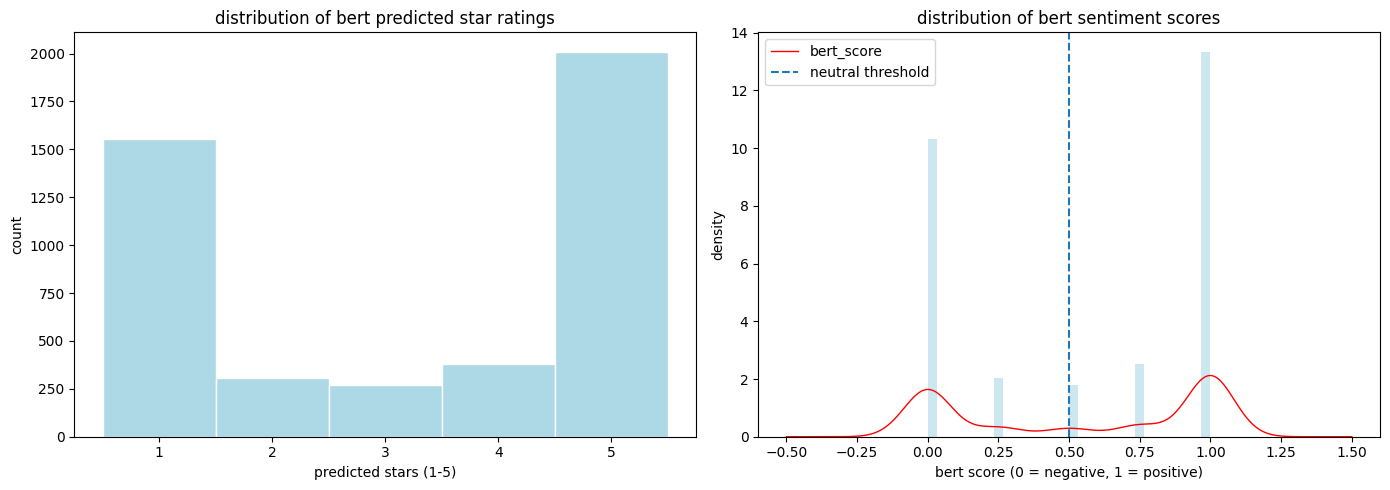

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted star distribution
axes[0].hist(data["bert_stars"], bins=5, range=(0.5, 5.5), color="lightblue", edgecolor="white")
axes[0].set_title("distribution of bert predicted star ratings")
axes[0].set_xlabel("predicted stars (1-5)")
axes[0].set_ylabel("count")
axes[0].set_xticks([1, 2, 3, 4, 5])

# normalized sentiment score distribution
axes[1].hist(data["bert_score"], bins=30, density=True, color="lightblue", alpha=0.6)
data["bert_score"].plot(kind="density", ax=axes[1], color="red", linewidth=1)
axes[1].axvline(0.5, linestyle="--", label="neutral threshold")
axes[1].set_title("distribution of bert sentiment scores")
axes[1].set_xlabel("bert score (0 = negative, 1 = positive)")
axes[1].set_ylabel("density")
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/3790758947.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data, labels=rating_labels, patch_artist=True)


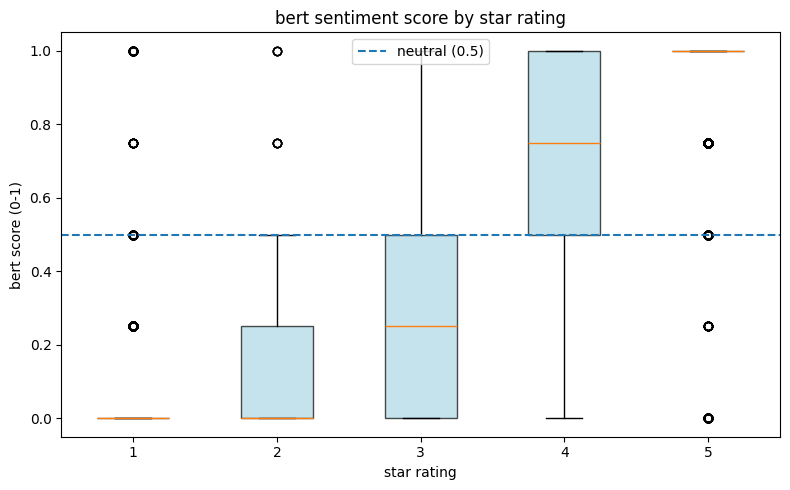

In [63]:
ratings = sorted(data["rating"].dropna().unique())
box_data = [data.loc[data["rating"] == r, "bert_score"] for r in ratings]
rating_labels = [str(int(r)) for r in ratings]

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(box_data, labels=rating_labels, patch_artist=True)
for patch in box["boxes"]:
    patch.set_facecolor("lightblue")
    patch.set_alpha(0.7)
ax.axhline(0.5, linestyle="--", label="neutral (0.5)")
ax.set_title("bert sentiment score by star rating")
ax.set_xlabel("star rating")
ax.set_ylabel("bert score (0-1)")
ax.legend()
plt.tight_layout()
plt.show()

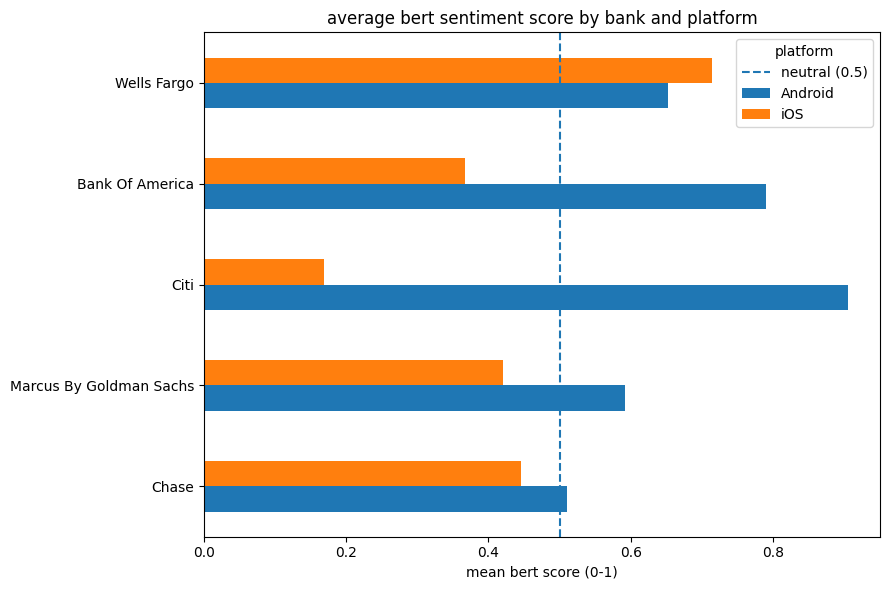

In [64]:
bert_by_bank_platform = (
    data
    .groupby(["bank", "platform"])
    .agg(mean_bert_score=("bert_score", "mean"), n_reviews=("review_id", "size"))
    .reset_index()
)

pivot_bank = bert_by_bank_platform.pivot(index="bank", columns="platform", values="mean_bert_score")
bank_order = pivot_bank.mean(axis=1).sort_values().index
pivot_bank = pivot_bank.loc[bank_order]

fig, ax = plt.subplots(figsize=(9, 6))
pivot_bank.plot(kind="barh", ax=ax)
ax.axvline(0.5, linestyle="--", label="neutral (0.5)")
ax.set_title("average bert sentiment score by bank and platform")
ax.set_xlabel("mean bert score (0-1)")
ax.set_ylabel("")
ax.legend(title="platform")
plt.tight_layout()
plt.show()

/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/4292788136.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data_bank, labels=[str(int(r)) for r in ratings_bank], patch_artist=True)
/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/4292788136.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data_bank, labels=[str(int(r)) for r in ratings_bank], patch_artist=True)
/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/4292788136.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data_bank, labels=[str(int(

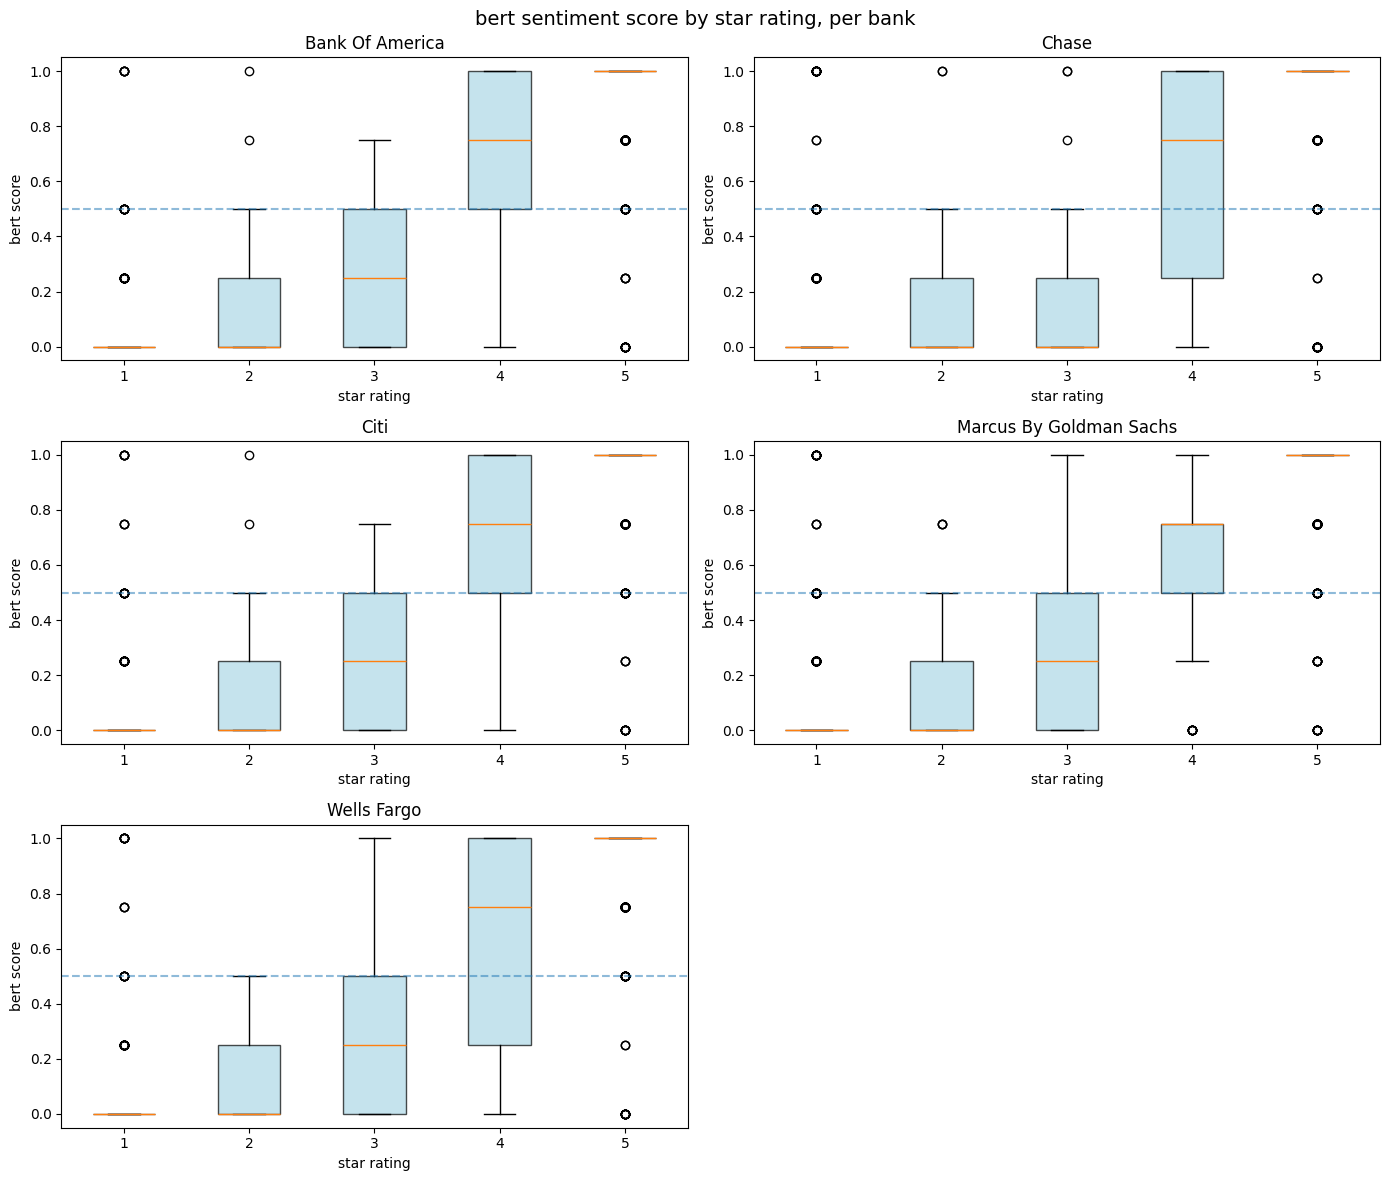

In [65]:
banks = sorted(data["bank"].unique())

fig, axes = plt.subplots(
    nrows=math.ceil(len(banks) / 2),
    ncols=2,
    figsize=(14, 4 * math.ceil(len(banks) / 2)),
    squeeze=False
)

for i, bank in enumerate(banks):
    ax = axes[i // 2, i % 2]
    bank_data = data[data["bank"] == bank]
    ratings_bank = sorted(bank_data["rating"].dropna().unique())
    box_data_bank = [bank_data.loc[bank_data["rating"] == r, "bert_score"] for r in ratings_bank]

    box = ax.boxplot(box_data_bank, labels=[str(int(r)) for r in ratings_bank], patch_artist=True)
    for patch in box["boxes"]:
        patch.set_facecolor("lightblue")
        patch.set_alpha(0.7)

    ax.axhline(0.5, linestyle="--", alpha=0.5)
    ax.set_title(bank)
    ax.set_xlabel("star rating")
    ax.set_ylabel("bert score")

for j in range(len(banks), math.ceil(len(banks) / 2) * 2):
    axes[j // 2, j % 2].axis("off")

fig.suptitle("bert sentiment score by star rating, per bank", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/1731142224.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data_plat, labels=[str(int(r)) for r in ratings_plat], patch_artist=True)
/var/folders/6n/nk79g1p12f5g8x_25z8415r80000gn/T/ipykernel_41009/1731142224.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data_plat, labels=[str(int(r)) for r in ratings_plat], patch_artist=True)


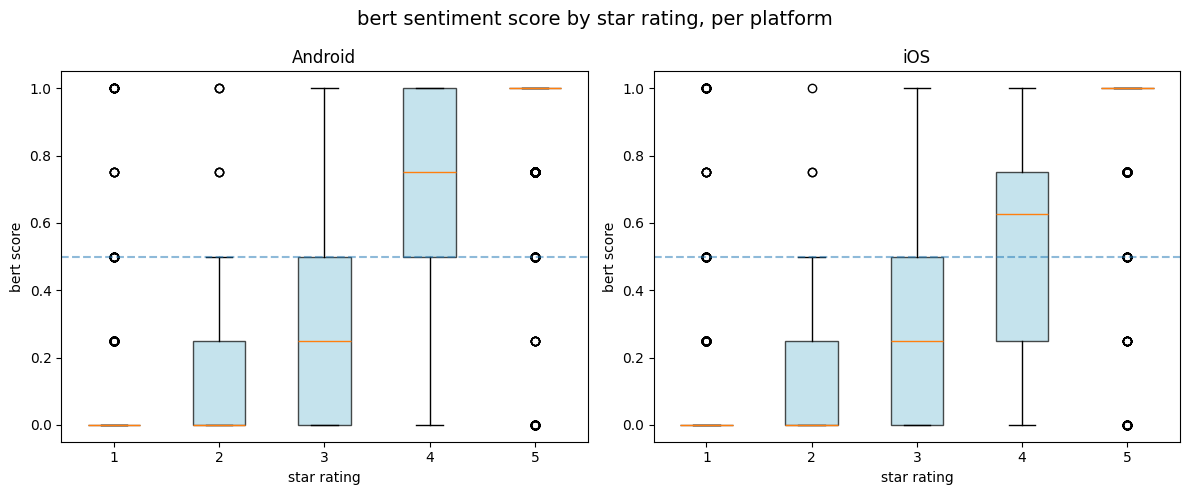

In [66]:
platforms = sorted(data["platform"].unique())

fig, axes = plt.subplots(1, len(platforms), figsize=(6 * len(platforms), 5), squeeze=False)

for i, platform in enumerate(platforms):
    ax = axes[0, i]
    plat_data = data[data["platform"] == platform]
    ratings_plat = sorted(plat_data["rating"].dropna().unique())
    box_data_plat = [plat_data.loc[plat_data["rating"] == r, "bert_score"] for r in ratings_plat]

    box = ax.boxplot(box_data_plat, labels=[str(int(r)) for r in ratings_plat], patch_artist=True)
    for patch in box["boxes"]:
        patch.set_facecolor("lightblue")
        patch.set_alpha(0.7)

    ax.axhline(0.5, linestyle="--", alpha=0.5)
    ax.set_title(platform)
    ax.set_xlabel("star rating")
    ax.set_ylabel("bert score")

fig.suptitle("bert sentiment score by star rating, per platform", fontsize=14)
plt.tight_layout()
plt.show()

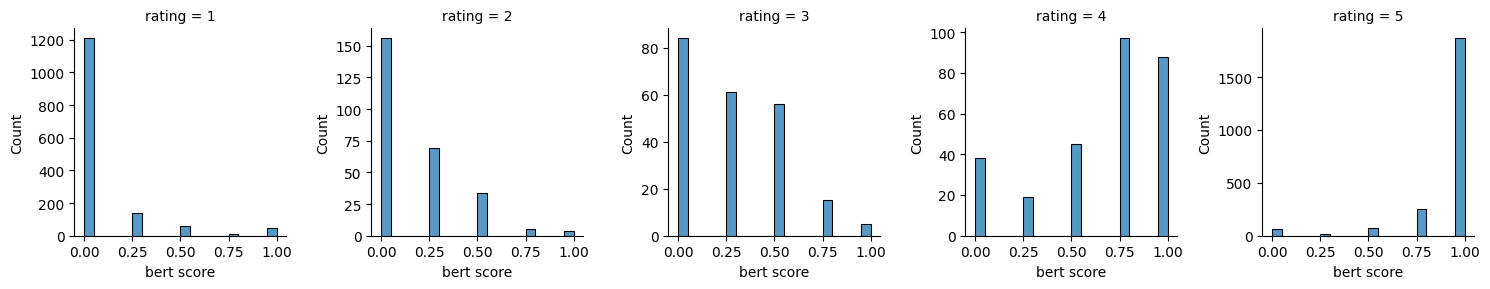

In [67]:
g = sns.FacetGrid(data, col="rating", col_wrap=5, sharex=True, sharey=False)
g.map(sns.histplot, "bert_score", bins=20)
g.set_titles(col_template="rating = {col_name}")
g.set_xlabels("bert score")
plt.tight_layout()
plt.show()

In [68]:
platform_test_data = data[["platform", "bert_score"]].dropna().copy()
platforms_unique = sorted(platform_test_data["platform"].unique())

if len(platforms_unique) == 2:
    group_1 = platform_test_data.loc[platform_test_data["platform"] == platforms_unique[0], "bert_score"]
    group_2 = platform_test_data.loc[platform_test_data["platform"] == platforms_unique[1], "bert_score"]

    mw_result = mannwhitneyu(group_1, group_2, alternative="two-sided")

    print("mann-whitney u test — platform comparison")
    print(f"platforms: {platforms_unique[0]} vs {platforms_unique[1]}")
    print(f"U statistic = {mw_result.statistic:.4f}")
    print(f"p-value = {mw_result.pvalue:.4g}")
else:
    print(f"found {len(platforms_unique)} platforms; test expects exactly 2")


mann-whitney u test — platform comparison
platforms: Android vs iOS
U statistic = 3379410.0000
p-value = 3.233e-93


In [69]:
cor_data = data[["rating", "bert_score"]].dropna()

r, p_value = pearsonr(cor_data["rating"], cor_data["bert_score"])
n = len(cor_data)
z = np.arctanh(r)
se = 1 / np.sqrt(n - 3)
ci_low, ci_high = np.tanh([z - 1.96 * se, z + 1.96 * se])

print("\npearson correlation — bert score vs star rating")
print(f"n = {n}")
print(f"correlation = {r:.4f}")
print(f"p-value = {p_value:.4g}")
print(f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")



pearson correlation — bert score vs star rating
n = 4518
correlation = 0.8615
p-value = 0
95% CI = [0.8538, 0.8688]


## BERT Predicted Rating vs Actual Rating

In [70]:
agreement = (data["bert_stars"] == data["rating"].astype(int)).mean()
print(f"\nexact star agreement (bert vs actual): {agreement:.3f}")

confusion = pd.crosstab(
    data["rating"].astype(int),
    data["bert_stars"],
    rownames=["actual rating"],
    colnames=["bert predicted stars"]
)
print(confusion)


exact star agreement (bert vs actual): 0.730
bert predicted stars     1    2   3    4     5
actual rating                                 
1                     1209  139  62   11    46
2                      156   69  34    5     4
3                       84   61  56   15     5
4                       38   19  45   97    88
5                       65   18  74  251  1867
